In [1]:
import numpy as np
import networkx as nx
import pickle

from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import QAOAAnsatz,  PauliEvolutionGate
from qiskit.transpiler.passes.routing.commuting_2q_gate_routing import SwapStrategy

from qiskit_aer import AerSimulator

# from qiskit_ibm_runtime.fake_provider import FakeFez, FakeAlgiers

from qopt_best_practices.sat_mapping import SATMapper

import copy
from qiskit.quantum_info import SparsePauliOp
from qiskit.converters import dag_to_circuit, circuit_to_dag
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

from qopt_best_practices.transpilation.qaoa_construction_pass import QAOAConstructionPass
from qopt_best_practices.transpilation import qaoa_swap_strategy_pm

from qiskit_optimization import QuadraticProgram

from qiskit.transpiler import PassManager
from qiskit.transpiler.passes import HighLevelSynthesis, InverseCancellation
from qiskit.circuit.library import CXGate

from qopt_best_practices.transpilation.swap_cancellation_pass import SwapToFinalMapping



In [2]:
from qiskit_ibm_runtime.fake_provider import FakeAlgiers, FakeFez


In [4]:
def circuit_to_graph(qc: QuantumCircuit, parameter) -> nx.Graph:
    """"QAOA Cost operator as a circuit to a graph"""
    qreg = qc.qregs[0]
    graph, edges = nx.Graph(), []
    graph.add_nodes_from(range(len(qreg)))
    seen_edges = set()

    for inst in qc.data:
        iop = inst.operation

        if len(iop.params) == 0 or parameter not in iop.params[0].parameters:
            continue

        if len(inst.qubits) == 1:
            edge = (qreg.index(inst.qubits[0]), qreg.index(inst.qubits[0]))
        elif len(inst.qubits) == 2:
            edge = (qreg.index(inst.qubits[0]), qreg.index(inst.qubits[1]))
        else:
            raise ValueError('Too many qubits in instruction')
        
        if edge in seen_edges:
            raise ValueError(f'Circuit contains edge {edge} multiple times')

        # logger.info(edge)
        seen_edges.add(edge)
        seen_edges.add(edge[::-1])

        param_expression = copy.deepcopy(iop.params[0])
        param_expression = param_expression.assign(next(iter(param_expression.parameters)), 1)
        weight = float(param_expression) / 2.0
        edges.append((edge[0], edge[1], weight))

    graph.add_weighted_edges_from(edges)
    return graph


def graph_to_operator(graph: nx.Graph, prefactor: float = 1.0) -> SparsePauliOp:
    pauli_list = []
    for node1, node2, data in graph.edges(data=True):
        paulis = ["I"] * len(graph)
        paulis[node1], paulis[node2] = "Z", "Z"
        if "weight" in data:
            weight = data["weight"] 
        else:
            print("No weight data")
            weight = 1.0
        pauli_list.append(("".join(paulis)[::-1], prefactor * weight))

    return SparsePauliOp.from_list(pauli_list)


def circuit_construction(
        singles,
        doubles,
        backend,
        swap_strat,
        edge_coloring,
        metadata,
        reps
):
    circuits_dict = {}
    n = len(doubles[0].paulis[0])

    doubles_circ = QAOAAnsatz(
        doubles,
        initial_state=QuantumCircuit(n),
        mixer_operator=QuantumCircuit(n),
        flatten=True
    )
    circuits_dict['doubles'] = doubles_circ
    print(doubles_circ.data)

    properties = {}

    def get_permutation(pass_, dag, time, property_set, count):
        properties["virtual_permutation_layout"] = property_set["virtual_permutation_layout"]

    
    config = {
        "num_layers": reps,
        "swap_strategy": swap_strat,
        "edge_coloring": edge_coloring,
        "construct_qaoa": False,
        "basis_gates":  ["sx", "x", "rz", "rzz", "cz", "id"]
    }
    pm = qaoa_swap_strategy_pm(config)
    tdoubles_circ = pm.run(doubles_circ, callback=get_permutation)
    circuits_dict["tdoubles"] = tdoubles_circ

    singles_circ = QuantumCircuit(n)
    singles_circ.append(PauliEvolutionGate(singles, time=tdoubles_circ.parameters[0]), range(n))
    tsingles = transpile(singles_circ, basis_gates=["rz"])
    cost_circ = tsingles.compose(tdoubles_circ, inplace=False)
    circuits_dict["cost_circuit"] = cost_circ

    construction_pass = QAOAConstructionPass(reps)
    construction_pass.property_set = properties
    transpiled_circ = dag_to_circuit(construction_pass.run(circuit_to_dag(cost_circ)))

    circuits_dict["circuit_to_sample"] = transpiled_circ

    if backend is not None:
        generic_pm = generate_preset_pass_manager(optimization_level=3, backend=backend, scheduling_method="alap")
        circuits_dict["backend"] = generic_pm.run(transpiled_circ)
        circuits_dict["backend"].metadata = metadata

    return circuits_dict

In [5]:
def get_objective_and_hamiltonian(data_file):
    with open(data_file, 'rb') as f:
        data = pickle.load(f)
    Q = data['Q']
    offset = data['offset']
    
    Q = np.triu(Q) * 2
    Q -= np.triu(np.triu(Q).T) / 2

    normalisation = np.max(np.abs(Q))
    Q = Q / normalisation
    offset = offset / normalisation

    mod = QuadraticProgram("QUBO test")
    mod.binary_var_list(Q.shape[0])
    mod.minimize(constant=offset, linear=None, quadratic=Q)
    hamiltonian, ising_offset = mod.to_ising()
    hamiltonian = hamiltonian.sort(weight=True)
    return mod.objective, hamiltonian, ising_offset

In [95]:
basis_gates=["sx", "x", "rz", "rzz", "cz", "id"]

In [16]:
filename = 'trivial'
p = 1

seed = 1
rng = np.random.default_rng(seed=seed)

backend_options = dict(
    method='statevector',
    device='GPU',
    precision='single',
    basis_gates=basis_gates
)
fake_fez = FakeFez()
fake_algiers = FakeAlgiers()

backend = AerSimulator.from_backend(fake_algiers, **backend_options)

data_file = f'/lustre/scratch127/qpg/jc59/out/oriented/qubo_data_{filename}.gfa.pkl'

_, hamiltonian, _ = get_objective_and_hamiltonian(data_file)
qc = QAOAAnsatz(
    cost_operator=hamiltonian,
    reps = p,
    flatten=True
)


def print_circuit_info(qc, circuit_name):
    print(f'{circuit_name} has {qc.count_ops().get("cz", 0) + qc.count_ops().get("rzz", 0) + qc.count_ops().get("cx", 0)} 2Q gates \
    and {qc.depth(lambda instr: len(instr.qubits) > 1)} 2Q depth')


NameError: name 'basis_gates' is not defined

In [9]:
coupling_g = nx.Graph(list(fake_algiers.coupling_map))
# nx.draw(coupling_g)

In [97]:
backend._basis_gates()

['sx', 'x', 'rz', 'rzz', 'cz', 'id']

In [98]:
transpiled_qc = transpile(qc, basis_gates=basis_gates, optimization_level=3, seed_transpiler=seed)

print_circuit_info(transpiled_qc, '(Transpiled) Circuit')

transpiled_backend_qc = transpile(qc, backend, basis_gates=basis_gates, optimization_level=3, seed_transpiler=seed)

print_circuit_info(transpiled_backend_qc, '(Transpiled backend) Circuit')

(Transpiled) Circuit has 159 2Q gates     and 39 2Q depth
(Transpiled backend) Circuit has 729 2Q gates     and 336 2Q depth


/nfs/users/nfs_j/jc59/quantumwork/pangenome/.venv/lib/python3.10/site-packages/qiskit/compiler/transpiler.py:269: UserWarning: Providing `coupling_map` and/or `basis_gates` along with `backend` is not recommended, as this will invalidate the backend's gate durations and error rates.
  pm = generate_preset_pass_manager(


In [99]:
print(transpiled_qc.count_ops())
print(transpiled_backend_qc.count_ops())

OrderedDict([('rzz', 159), ('rz', 126), ('sx', 63)])
OrderedDict([('sx', 1203), ('cz', 570), ('rzz', 159), ('rz', 126)])


In [24]:
# transpiled_qc.draw(fold=-1)

In [25]:
# transpiled_backend_qc.draw(fold=-1)

In [236]:
graph = circuit_to_graph(qc, qc.parameters[p])

swap_strat = SwapStrategy.from_line(range(graph.order()))
edge_coloring = {(idx, idx + 1): (idx + 1) % 2 for idx in range(graph.order())}

In [345]:
from __future__ import annotations

from typing import Tuple

import numpy as np

from qiskit.exceptions import QiskitError
from qiskit.dagcircuit import DAGCircuit
from qiskit.transpiler import TransformationPass
from qiskit.quantum_info import SparsePauliOp, Pauli



from collections.abc import Iterable

from qiskit.circuit import Gate, Qubit, Clbit
from qiskit.dagcircuit import DAGOpNode

class CommutingBlock(Gate):
    """A gate made of commuting two-qubit gates.

    This gate is intended for use with commuting swap strategies to make it convenient
    for the swap strategy router to identify which blocks of operations commute.
    """

    def __init__(self, node_block: Iterable[DAGOpNode]) -> None:
        """
        Args:
            node_block: A block of nodes that commute.

        Raises:
            QiskitError: If the nodes in the node block do not apply to two-qubits.
        """
        qubits: set[Qubit] = set()
        cbits: set[Clbit] = set()
        for node in node_block:
            # if len(node.qargs) != 2:
            #     raise QiskitError(f"Node {node.name} does not apply to two-qubits.")

            qubits.update(node.qargs)
            cbits.update(node.cargs)

        if cbits:
            raise QiskitError(
                f"{self.__class__.__name__} does not accept nodes with classical bits."
            )

        super().__init__(
            "commuting_block", num_qubits=len(qubits), params=[], label="Commuting gates"
        )
        self.node_block = node_block
        self.qubits = qubits

    def __iter__(self):
        """Iterate through the nodes in the block."""
        return iter(self.node_block)


class FindCommutingPauliEvolutionsMulti(TransformationPass):
    """Finds :class:`.PauliEvolutionGate`s where the operators, that are evolved, all commute."""

    def run(self, dag: DAGCircuit) -> DAGCircuit:
        """Check for :class:`.PauliEvolutionGate`s where the summands all commute.

        Args:
            The DAG circuit in which to look for the commuting evolutions.

        Returns:
            The dag in which :class:`.PauliEvolutionGate`s made of commuting two-qubit Paulis
            have been replaced with :class:`.Commuting2qBlocks`` gate instructions. These gates
            contain nodes of two-qubit :class:`.PauliEvolutionGate`s.
        """

        for node in dag.op_nodes():
            if isinstance(node.op, PauliEvolutionGate):
                operator = node.op.operator
                if self.single_qubit_terms_only(operator):
                    continue

                if self.summands_commute(node.op.operator):
                    sub_dag = self._decompose(dag, node.op)

                    block_op = CommutingBlock(set(sub_dag.op_nodes()))
                    wire_order = {
                        wire: idx
                        for idx, wire in enumerate(sub_dag.qubits)
                        if wire not in sub_dag.idle_wires()
                    }
                    dag.replace_block_with_op([node], block_op, wire_order)

        return dag

    @staticmethod
    def single_qubit_terms_only(operator: SparsePauliOp) -> bool:
        """Determine if the Paulis are made of single qubit terms only.

        Args:
            operator: The operator to check if it consists only of single qubit terms.

        Returns:
            True if the operator consists of only single qubit terms (like ``IIX + IZI``),
            and False otherwise.
        """

        for pauli in operator.paulis:
            if sum(np.logical_or(pauli.x, pauli.z)) > 1:
                return False

        return True

    @staticmethod
    def summands_commute(operator: SparsePauliOp) -> bool:
        """Check if all summands in the evolved operator commute.

        Args:
            operator: The operator to check if all its summands commute.

        Returns:
            True if all summands commute, False otherwise.
        """
        # get a list of summands that commute
        commuting_subparts = operator.paulis.group_qubit_wise_commuting()

        # if all commute we only have one summand!
        return len(commuting_subparts) == 1

    @staticmethod
    def _pauli_to_edge(pauli: Pauli) -> Tuple[int, ...]:
        """Convert a pauli to an edge.

        Args:
            pauli: A pauli that is converted to a string to find out where non-identity
                Paulis are.

        Returns:
            A tuple representing where the Paulis are. For example, the Pauli "IZIZ" will
            return (0, 2) since virtual qubits 0 and 2 interact.

        Raises:
            QiskitError: If the pauli does not exactly have two non-identity terms.
        """
        edge = tuple(np.logical_or(pauli.x, pauli.z).nonzero()[0])

        # if len(edge) != 2:
        #     raise QiskitError(f"{pauli} does not have length two.")

        return edge

    def _decompose(self, dag: DAGCircuit, op: PauliEvolutionGate) -> DAGCircuit:
        """Decompose the SparsePauliOp into local-qubit.

        Args:
            dag: The dag needed to get access to qubits.
            op: The operator with all the Pauli terms we need to apply.

        Returns:
            A dag made of two-qubit :class:`.PauliEvolutionGate`.
        """
        sub_dag = dag.copy_empty_like()

        required_paulis = {
            self._pauli_to_edge(pauli): (pauli, coeff)
            for pauli, coeff in zip(op.operator.paulis, op.operator.coeffs)
        }

        for edge, (pauli, coeff) in required_paulis.items():
            
            qubits = [dag.qubits[edge[i]] for i in range(len(edge))]

            simple_pauli = Pauli(pauli.to_label().replace("I", ""))

            pauli_2q = PauliEvolutionGate(simple_pauli, op.time * np.real(coeff))
            sub_dag.apply_operation_back(pauli_2q, qubits)

        return sub_dag


In [346]:
x = {}
y = tuple(sorted([2,1]))
x[y] = 1


In [3]:
from qiskit.transpiler.coupling import CouplingMap
import math

class ExtendedSwapStrategy(SwapStrategy):
    def __init__(
        self, coupling_map: CouplingMap, swap_layers: tuple[tuple[tuple[int, int], ...], ...]
    ) -> None:
        self._distances = {}
        super().__init__(coupling_map, swap_layers)
    
    def distance_nodes(self, nodes: tuple) -> int | float:
        nodes = tuple(sorted(nodes))
        distance = self._distances.get(nodes, None)
        if distance is not None:
            return distance
        
        if len(nodes) < 2:
            return 0
        
        for i in range(len(self._swap_layers) + 1):
            cmap = self.swapped_coupling_map(i)
            neighbouring = []
            for node in nodes:
                neighbouring.append(
                    any([cmap.distance(node, other) == 1 for other in nodes])
                )
            
            if all(neighbouring):
                self._distances[nodes] = i
                return i
        return math.inf

NameError: name 'SwapStrategy' is not defined

In [355]:
from qiskit.transpiler.exceptions import TranspilerError
from qiskit.transpiler.layout import Layout
from collections import defaultdict


class CommutingGateRouter(TransformationPass):
    def __init__(
        self,
        swap_strategy: ExtendedSwapStrategy | None = None,
        edge_coloring: dict[tuple[int, int], int] | None = None,
    ) -> None:
        r"""
        Args:
            swap_strategy: An instance of a :class:`.SwapStrategy` that holds the swap layers
                that are used, and the order in which to apply them, to map the instruction to
                the hardware. If this field is not given, it should be contained in the
                property set of the pass. This allows other passes to determine the most
                appropriate swap strategy at run-time.
            edge_coloring: An optional edge coloring of the coupling map (I.e. no two edges that
                share a node have the same color). If the edge coloring is given then the commuting
                gates that can be simultaneously applied given the current qubit permutation are
                grouped according to the edge coloring and applied according to this edge
                coloring. Here, a color is an int which is used as the index to define and
                access the groups of commuting gates that can be applied simultaneously.
                If the edge coloring is not given then the sets will be built-up using a
                greedy algorithm. The edge coloring is useful to position gates such as
                ``RZZGate``\s next to swap gates to exploit CX cancellations.
        """
        super().__init__()
        self._swap_strategy = swap_strategy
        self._bit_indices: dict[Qubit, int] | None = None
        self._edge_coloring = edge_coloring

    def run(self, dag: DAGCircuit) -> DAGCircuit:
        """Run the pass by decomposing the nodes it applies on.

        Args:
            dag: The dag to which we will add swaps.

        Returns:
            A dag where swaps have been added for the intended gate type.

        Raises:
            TranspilerError: If the swap strategy was not given at init time and there is
                no swap strategy in the property set.
            TranspilerError: If the quantum circuit contains more than one qubit register.
            TranspilerError: If there are qubits that are not contained in the quantum register.
        """
        if self._swap_strategy is None:
            swap_strategy = self.property_set["swap_strategy"]

            if swap_strategy is None:
                raise TranspilerError("No swap strategy given at init or in the property set.")
        else:
            swap_strategy = self._swap_strategy

        if len(dag.qregs) != 1:
            raise TranspilerError(
                f"{self.__class__.__name__} runs on circuits with one quantum register."
            )

        if len(dag.qubits) != next(iter(dag.qregs.values())).size:
            raise TranspilerError("Circuit has qubits not contained in the qubit register.")

        # Fix output permutation -- copied from ElidePermutations
        input_qubit_mapping = {qubit: index for index, qubit in enumerate(dag.qubits)}
        self.property_set["original_layout"] = Layout(input_qubit_mapping)
        if self.property_set["original_qubit_indices"] is None:
            self.property_set["original_qubit_indices"] = input_qubit_mapping

        new_dag = dag.copy_empty_like()
        current_layout = Layout.generate_trivial_layout(*dag.qregs.values())

        # Used to keep track of nodes that do not decompose using swap strategies.
        accumulator = new_dag.copy_empty_like()
        cannot_implement = []
        for node in dag.topological_op_nodes():
            if isinstance(node.op, CommutingBlock):

                # Check that the swap strategy creates enough connectivity for the node.
                cannot_implement.extend(self._check_edges(dag, node, swap_strategy))

                # Compose any accumulated non-swap strategy gates to the dag
                accumulator = self._compose_non_swap_nodes(accumulator, current_layout, new_dag)

                # Decompose the swap-strategy node and add to the dag.
                new_dag.compose(self.swap_decompose(dag, node, current_layout, swap_strategy))
            else:
                print('Not commuting block')
                accumulator.apply_operation_back(node.op, node.qargs, node.cargs)

        for sub_node in cannot_implement:
            accumulator.apply_operation_back(sub_node.op, sub_node.qargs, sub_node.cargs)
        
        for op in cannot_implement:
            print(op.op)
        self._compose_non_swap_nodes(accumulator, current_layout, new_dag)

        self.property_set["virtual_permutation_layout"] = current_layout

        return new_dag

    def _compose_non_swap_nodes(
        self, accumulator: DAGCircuit, layout: Layout, new_dag: DAGCircuit
    ) -> DAGCircuit:
        """Add all the non-swap strategy nodes that we have accumulated up to now.

        This method also resets the node accumulator to an empty dag.

        Args:
            layout: The current layout that keeps track of the swaps.
            new_dag: The new dag that we are building up.
            accumulator: A DAG to keep track of nodes that do not decompose
                using swap strategies.

        Returns:
            A new accumulator with the same registers as ``new_dag``.
        """
        # Add all the non-swap strategy nodes that we have accumulated up to now.
        order = layout.reorder_bits(new_dag.qubits)
        order_bits: list[int | None] = [None] * len(layout)
        for idx, val in enumerate(order):
            order_bits[val] = idx

        new_dag.compose(accumulator, qubits=order_bits)

        # Re-initialize the node accumulator
        return new_dag.copy_empty_like()

    def _position_in_cmap(self, dag: DAGCircuit, indices: tuple[int], layout: Layout) -> tuple[int, ...]:
        """A helper function to track the movement of virtual qubits through the swaps.

        Args:
            indices: The index of decision variables (i.e. virtual qubit).
            layout: The current layout that takes into account previous swap gates.

        Returns:
            The position in the coupling map of the virtual qubits as a tuple.
        """
        bits = tuple([dag.find_bit(layout.get_physical_bits()[i]).index for i in indices])

        return bits

    def _build_sub_layers(
        self, current_layer: dict[tuple[int, int], Gate]
    ) -> list[dict[tuple[int, int], Gate]]:
        """A helper method to build-up sets of gates to simultaneously apply.

        This is done with an edge coloring if the ``edge_coloring`` init argument was given or with
        a greedy algorithm if not. With an edge coloring all gates on edges with the same color
        will be applied simultaneously. These sublayers are applied in the order of their color,
        which is an int, in increasing color order.

        Args:
            current_layer: All gates in the current layer can be applied given the qubit ordering
                of the current layout. However, not all gates in the current layer can be applied
                simultaneously. This function creates sub-layers by building up sub-layers
                of gates. All gates in a sub-layer can simultaneously be applied given the coupling
                map and current qubit configuration.

        Returns:
             A list of gate dicts that can be applied. The gates a position 0 are applied first.
             A gate dict has the qubit tuple as key and the gate to apply as value.
        """
        if self._edge_coloring is not None:
            return self._edge_coloring_build_sub_layers(current_layer)
        else:
            return self._greedy_build_sub_layers(current_layer)

    def _edge_coloring_build_sub_layers(
        self, current_layer: dict[tuple[int, int], Gate]
    ) -> list[dict[tuple[int, int], Gate]]:
        """The edge coloring method of building sub-layers of commuting gates."""
        sub_layers: list[dict[tuple[int, int], Gate]] = [
            {} for _ in set(self._edge_coloring.values())
        ]
        for edge, gate in current_layer.items():
            color = self._edge_coloring[edge]
            sub_layers[color][edge] = gate

        return sub_layers

    @staticmethod
    def _greedy_build_sub_layers(
        current_layer: dict[tuple[int, int], Gate]
    ) -> list[dict[tuple[int, int], Gate]]:
        """The greedy method of building sub-layers of commuting gates."""
        sub_layers = []
        while len(current_layer) > 0:
            current_sub_layer, remaining_gates = {}, {}
            blocked_vertices: set[tuple] = set()

            for edge, evo_gate in current_layer.items():
                if blocked_vertices.isdisjoint(edge):
                    current_sub_layer[edge] = evo_gate

                    # A vertex becomes blocked once a gate is applied to it.
                    blocked_vertices = blocked_vertices.union(edge)
                else:
                    remaining_gates[edge] = evo_gate

            current_layer = remaining_gates
            sub_layers.append(current_sub_layer)

        return sub_layers

    def swap_decompose(
        self, dag: DAGCircuit, node: DAGOpNode, current_layout: Layout, swap_strategy: ExtendedSwapStrategy
    ) -> DAGCircuit:
        """Take an instance of :class:`.Commuting2qBlock` and map it to the coupling map.

        The mapping is done with the swap strategy.

        Args:
            dag: The dag which contains the :class:`.Commuting2qBlock` we route.
            node: A node whose operation is a :class:`.Commuting2qBlock`.
            current_layout: The layout before the swaps are applied. This function will
                modify the layout so that subsequent gates can be properly composed on the dag.
            swap_strategy: The swap strategy used to decompose the node.

        Returns:
            A dag that is compatible with the coupling map where swap gates have been added
            to map the gates in the :class:`.Commuting2qBlock` to the hardware.
        """
        trivial_layout = Layout.generate_trivial_layout(*dag.qregs.values())
        gate_layers = self._make_op_layers(dag, node.op, current_layout, swap_strategy)

        # Iterate over and apply gate layers
        max_distance = max(gate_layers.keys())

        circuit_with_swap = QuantumCircuit(len(dag.qubits))

        for i in range(max_distance + 1):
            # Get current layer and replace the problem indices j,k by the corresponding
            # positions in the coupling map. The current layer corresponds
            # to all the gates that can be applied at the ith swap layer.
            current_layer = {}
            for indices, local_gate in gate_layers.get(i, {}).items():
                current_layer[self._position_in_cmap(dag, indices, current_layout)] = local_gate

            # Not all gates that are applied at the ith swap layer can be applied at the same
            # time. We therefore greedily build sub-layers.
            sub_layers = self._build_sub_layers(current_layer)

            # Apply sub-layers
            for sublayer in sub_layers:
                for edge, local_gate in sublayer.items():
                    circuit_with_swap.append(local_gate, edge)

            # Apply SWAP gates
            if i < max_distance:
                for swap in swap_strategy.swap_layer(i):
                    try:
                        (j, k) = [trivial_layout.get_physical_bits()[vertex] for vertex in swap]
                    except KeyError:
                        print(swap)
                        print(trivial_layout.get_physical_bits())
                        raise KeyError()

                    circuit_with_swap.swap(j, k)
                    current_layout.swap(j, k)

        return circuit_to_dag(circuit_with_swap)

    def _make_op_layers(
        self, dag: DAGCircuit, op: CommutingBlock, layout: Layout, swap_strategy: ExtendedSwapStrategy
    ) -> dict[int, dict[tuple, Gate]]:
        """Creates layers of two-qubit gates based on the distance in the swap strategy."""

        gate_layers: dict[int, dict[tuple, Gate]] = defaultdict(dict)

        for node in op.node_block:
            edge = tuple([dag.find_bit(node.qargs[i]).index for i in range(len(node.qargs))])
            if len(edge) == 0:
                print(node.op)
            # edge = (dag.find_bit(node.qargs[0]).index, dag.find_bit(node.qargs[1]).index)

            v_bits = layout.get_virtual_bits()        
            bits = tuple([v_bits[dag.qubits[edge[i]]] for i in range(len(edge))])

            distance = swap_strategy.distance_nodes(bits)
            
            if distance != math.inf:
                gate_layers[distance][edge] = node.op

        return gate_layers

    def _check_edges(self, dag: DAGCircuit, node: DAGOpNode, swap_strategy: ExtendedSwapStrategy):
        """Check if the swap strategy can create the required connectivity.

        Args:
            node: The dag node for which to check if the swap strategy provides enough connectivity.
            swap_strategy: The swap strategy that is being used.

        Raises:
            TranspilerError: If there is an edge that the swap strategy cannot accommodate
                and if the pass has been configured to raise on such issues.
        """
        cannot_implement = []
        for sub_node in node.op:
            bits = tuple([dag.find_bit(sub_node.qargs[i]).index for i in range(len(sub_node.qargs))])
            distance = swap_strategy.distance_nodes(bits)
            if distance == math.inf:
                cannot_implement.append(sub_node)
                # raise TranspilerError(
                #     f"{swap_strategy} cannot implement operator on {bits}."
                # )
        return cannot_implement
            


In [237]:
remapped_g, sat_map, min_sat_layers = SATMapper(timeout=5).remap_graph_with_sat(
    graph=graph, swap_strategy=swap_strat
)

In [238]:
cost_op = graph_to_operator(remapped_g)
singles = cost_op[cost_op.paulis.z.sum(axis=-1) == 1]
doubles = cost_op[cost_op.paulis.z.sum(axis=-1) == 2]

doubles = doubles + SparsePauliOp(
    'ZZZ' + 'I' * (len(doubles.paulis[0])-3),
    1
)

n = len(doubles[0].paulis[0])

doubles_circ = QuantumCircuit(n)
doubles_circ.append(PauliEvolutionGate(doubles), range(n))
# for term in doubles:
#     doubles_circ.append(PauliEvolutionGate(SparsePauliOp('ZZ', [1]), np.real(term.coeffs[0])), [i for i in range(n) if term.paulis.z[0][i] == True ])


In [251]:
print(doubles[-5:])

SparsePauliOp(['IIIIIIIIIZIIIIIZIIIII', 'IIIIIIIIIIIIIIZIIIIZI', 'IIIIIIIIIZIIIIZIIIIII', 'IIIIIIIIIZIIIIIIIIIZI', 'ZZZIIIIIIIIIIIIIIIIII'],
              coeffs=[0.15625 +0.j, 0.171875+0.j, 0.15625 +0.j, 0.15625 +0.j, 1.      +0.j])


In [312]:


pm = PassManager(
    [
        HighLevelSynthesis(basis_gates=["PauliEvolution"]), # Not needed if set up circuit as PauliEvolutionGate
        FindCommutingPauliEvolutionsMulti(), # Doesn't do anything if all Z operators, except rename PauliEvolutionGate to commuting_2q_block
        # Will error on multi-qubit gates, but I don't think out of necessity - rewrite?
        CommutingGateRouter(
            extended_swap_strat,
        ),
        SwapToFinalMapping(),
        HighLevelSynthesis(basis_gates=["sx", "x", "rz", "cx", "id"]),
        # HighLevelSynthesis(basis_gates=["sx", "x", "rz", "cz", "h", "id"]),
        # HighLevelSynthesis(basis_gates=basis_gates),
        InverseCancellation(gates_to_cancel=[CXGate()]),
    ]
)




In [281]:
print(doubles_circ.count_ops())
def callback_func(**kwargs):
    pass_ = kwargs['pass_']
    dag = kwargs['dag']
    print(pass_, dag.properties())
tdoubles = pm.run(doubles_circ, callback=callback_func)

OrderedDict([('PauliEvolution', 1)])
<qiskit.transpiler.passes.synthesis.high_level_synthesis.HighLevelSynthesis object at 0x7f46ec108be0> {'depth': 1, 'qubits': 21, 'size': 1, 'width': 21, 'bits': 0, 'factors': 1, 'operations': {'PauliEvolution': 1}}
<__main__.FindCommutingPauliEvolutionsMulti object at 0x7f46ec10a410> {'size': 1, 'qubits': 21, 'bits': 0, 'factors': 1, 'depth': 1, 'width': 21, 'operations': {'commuting_block': 1}}
Not checking if strategy supports higher order: (<Qubit register=(21, "q"), index=18>, <Qubit register=(21, "q"), index=19>, <Qubit register=(21, "q"), index=20>) 
<__main__.CommutingGateRouter object at 0x7f46ec3eafe0> {'width': 21, 'operations': {'PauliEvolution': 160, 'swap': 180}, 'factors': 1, 'qubits': 21, 'depth': 39, 'size': 340, 'bits': 0}
<qopt_best_practices.transpilation.swap_cancellation_pass.SwapToFinalMapping object at 0x7f46ec3e8c70> {'size': 339, 'depth': 39, 'factors': 1, 'width': 21, 'operations': {'PauliEvolution': 160, 'swap': 179}, 'qub

In [240]:
print_circuit_info(tdoubles, '(Transpiled) Doubles Circuit')
print(tdoubles.count_ops())

(Transpiled) Doubles Circuit has 585 2Q gates     and 62 2Q depth
OrderedDict([('cx', 585), ('rz', 160)])


In [241]:
ttdoubles = transpile(tdoubles, basis_gates=["h", "rz", "cz"])

In [242]:
print_circuit_info(ttdoubles, '(Transpiled) Doubles Circuit')
print(ttdoubles.count_ops())

(Transpiled) Doubles Circuit has 583 2Q gates     and 60 2Q depth
OrderedDict([('h', 1154), ('cz', 583), ('rz', 169)])


In [243]:
tttdoubles = transpile(ttdoubles, basis_gates=["sx", "rz", "cz"])

In [244]:
print_circuit_info(tttdoubles, '(Transpiled) Doubles Circuit')
print(tttdoubles.count_ops())

(Transpiled) Doubles Circuit has 583 2Q gates     and 60 2Q depth
OrderedDict([('sx', 1256), ('rz', 952), ('cz', 583)])


In [245]:
qaoa_doubles = QAOAAnsatz(
    doubles,
    mixer_operator=QuantumCircuit(n),
    initial_state=QuantumCircuit(n)
)
tqaoa = transpile(qaoa_doubles, basis_gates=["sx", "rz", "cz", "x"])

In [246]:
print_circuit_info(tqaoa, '(Transpiled) qaoa Circuit')
print(tqaoa.count_ops())

(Transpiled) qaoa Circuit has 322 2Q gates     and 78 2Q depth
OrderedDict([('rz', 603), ('sx', 424), ('cz', 322)])


In [247]:
backend._basis_gates()

['sx', 'x', 'rz', 'rzz', 'cz', 'id']

In [248]:
backend_tqaoa = transpile(tqaoa, backend=backend, basis_gates=basis_gates)
backend_tttdoubles = transpile(tttdoubles, backend=backend, basis_gates=basis_gates)

print_circuit_info(backend_tqaoa, '(Backend) qaoa Circuit')
print(backend_tqaoa.count_ops())

print_circuit_info(backend_tttdoubles, '(Backend) ttt_doubles Circuit')
print(backend_tttdoubles.count_ops())

(Backend) qaoa Circuit has 851 2Q gates     and 298 2Q depth
OrderedDict([('sx', 1382), ('cz', 851), ('rz', 544), ('x', 1)])
(Backend) ttt_doubles Circuit has 583 2Q gates     and 60 2Q depth
OrderedDict([('sx', 1238), ('rz', 955), ('cz', 580), ('x', 8), ('rzz', 3)])


/nfs/users/nfs_j/jc59/quantumwork/pangenome/.venv/lib/python3.10/site-packages/qiskit/compiler/transpiler.py:269: UserWarning: Providing `coupling_map` and/or `basis_gates` along with `backend` is not recommended, as this will invalidate the backend's gate durations and error rates.
  pm = generate_preset_pass_manager(


In [249]:
cost_op = cost_op.sort(weight=True)
cost_op[-5:]

SparsePauliOp(['ZIIIIIIIZIIIIIIIIIIII', 'ZIIIIIIZIIIIIIIIIIIII', 'ZIIIZIIIIIIIIIIIIIIII', 'ZIZIIIIIIIIIIIIIIIIII', 'ZZIIIIIIIIIIIIIIIIIII'],
              coeffs=[0.15625  +0.j, 0.15625  +0.j, 0.0390625+0.j, 0.1953125+0.j, 0.0390625+0.j])

In [306]:
n = len(doubles[0].paulis[0])

cost_circ = QuantumCircuit(n)
cost_circ.append(PauliEvolutionGate(cost_op), range(n))
tcost = pm.run(cost_circ, callback=callback_func)
ttcost = transpile(tcost, basis_gates=["h", "rz", "cz"])
tttcost = transpile(ttcost, basis_gates=["sx", "rz", "cz"])
backend_tcost = transpile(tttcost, backend=backend, basis_gates=basis_gates)

qaoa_cost_op = QAOAAnsatz(
    cost_op,
    mixer_operator=QuantumCircuit(n),
    initial_state=QuantumCircuit(n)
)
tqaoa = transpile(qaoa_cost_op, basis_gates=["sx", "rz", "cz"])
backend_tqaoa = transpile(tqaoa, backend=backend, basis_gates=basis_gates)



print_circuit_info(backend_tcost, '(Backend) t_cost Circuit')
print(backend_tcost.count_ops())

print_circuit_info(backend_tqaoa, '(Backend) qaoa Circuit')
print(backend_tqaoa.count_ops())


<qiskit.transpiler.passes.synthesis.high_level_synthesis.HighLevelSynthesis object at 0x7f47fa93a7a0> {'qubits': 21, 'bits': 0, 'factors': 1, 'width': 21, 'size': 1, 'operations': {'PauliEvolution': 1}, 'depth': 1}
<__main__.FindCommutingPauliEvolutionsMulti object at 0x7f46ed60efe0> {'qubits': 21, 'bits': 0, 'depth': 1, 'operations': {'commuting_block': 1}, 'factors': 1, 'size': 1, 'width': 21}
(5, 6) 0
(1,) 0
(1, 12) 15
(3, 16) 14
(10,) 0
(8, 13) 2
(5, 18) 14
(7, 18) 15
(8, 17) 4
(7, 9) 8
(14, 15) 0
(0, 13) 6
(4, 20) 8
(3, 10) 17
(1, 7) 4
(10, 14) 8
(13, 18) 18
(0, 5) 2
(16,) 0
(8, 10) 11
(11, 18) 17
(2, 17) 7
(7,) 0
(0, 18) 11
(19,) 0
(2, 13) 5
(6, 12) 11
(10, 11) 0
(2, 5) 1
(6, 13) 3
(18, 19) 0
(16, 19) 1
(17,) 0
(1, 14) 14
(15, 17) 16
(1, 6) 18
(4, 12) 12
(11,) 0
(3, 17) 10
(13, 14) 0
(4, 10) 13
(0, 20) 10
(0, 15) 7
(10, 13) 1
(5, 11) 8
(17, 19) 18
(3, 7) 5
(7, 13) 10
(8, 20) 6
(3, 18) 13
(9, 13) 11
(2, 15) 6
(5, 13) 9
(13, 17) 15
(3, 4) 0
(11, 12) 0
(4, 15) 5
(0, 16) 12
(7, 8) 0


/nfs/users/nfs_j/jc59/quantumwork/pangenome/.venv/lib/python3.10/site-packages/qiskit/compiler/transpiler.py:269: UserWarning: Providing `coupling_map` and/or `basis_gates` along with `backend` is not recommended, as this will invalidate the backend's gate durations and error rates.
  pm = generate_preset_pass_manager(


In [206]:
sorted_cost = cost_op.sort(weight=True)
sorted_cost[-1]

SparsePauliOp(['ZZIIIIIIIIIIIIIIIIIII'],
              coeffs=[0.0390625+0.j])

In [ ]:
import numpy as np
import re
import gfapy
import networkx as nx

from itertools import combinations

from qiskit import transpile
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import QAOAAnsatz


from sympy import Poly, Symbol

from qiskit_aer import AerSimulator
from qiskit_ibm_runtime.fake_provider import FakeFez

from pysat.formula import CNF, IDPool
from pysat.solvers import Solver
from qiskit.transpiler.passes.routing.commuting_2q_gate_routing import SwapStrategy

class Binary(Symbol):
    def _eval_power(self, other):
        return self
    
    
def monomial_to_pauli(monomial, size):
    indices = [int(re.search(r'[0-9]+', atom.name).group(0)) for atom in monomial.atoms()]
    pauli_str = ['I'] * size
    for i in indices:
        pauli_str[i] = 'Z'
    return ''.join(pauli_str)


def two_qubit_count(qc):
    return qc.count_ops().get("cz", 0) + qc.count_ops().get("rzz", 0) + qc.count_ops().get("cx", 0)


def depth(qc):
    return qc.depth(lambda instr: len(instr.qubits) > 1)


def bin_rep(k):
    return [int(x) for x in np.binary_repr(k, n)[::-1]]

In [327]:
filepath = f'/nfs/users/nfs_j/jc59/quantumwork/pangenome/data/{filename}.gfa'

gfa = gfapy.Gfa.from_file(filepath, vlevel=0)
copy_numbers = [1,1,1]

In [328]:
graph = nx.DiGraph()
for index, segment_line in enumerate(gfa.segments):
    graph.add_node(f'{segment_line.name}_+', weight=copy_numbers[index], start=segment_line.st)
    graph.add_node(f'{segment_line.name}_-', weight=copy_numbers[index], start=segment_line.st)
for edge_line in gfa.edges:
    v1 = edge_line.sid1
    v2 = edge_line.sid2
    graph.add_edges_from([
        (f'{v1.name}_{v1.orient}', f'{v2.name}_{v2.orient}'),
    ])
    v1.invert()
    v2.invert()
    graph.add_edges_from([
        (f'{v2.name}_{v2.orient}', f'{v1.name}_{v1.orient}'),
    ])

nodes = list(graph.nodes)
N = len(nodes)
n = int(np.ceil(np.log2(N+1)))
total_weight = int(sum(graph.nodes[node]["weight"] for node in nodes) / 2)
T = int(1.1 * total_weight)

x = [[Binary(f'x[{t}][{i}]') for i in range(n)] for t in range(T)]

In [329]:
constraint = sum([
    1 - sum([
        np.prod([
            1 - x[t][k] - bin_rep(i)[k] + 2 * x[t][k] * bin_rep(i)[k]
        for k in range(n)]) * sum([
            np.prod([
                1 - x[t+1][k] - bin_rep(j)[k] + 2 * x[t+1][k] * bin_rep(j)[k]
            for k in range(n)])
        for j in [nodes.index(nbr) for nbr in graph.neighbors(nodes[i])]])
    for i in range(N)])
for t in range(T-1)])

obj = sum([
    (
        sum([
            np.prod([
                1 - x[t][k] - bin_rep(i)[k] + 2 * x[t][k] * bin_rep(i)[k]
            for k in range(n)])
            + np.prod([
                1 - x[t][k] - bin_rep(i+1)[k] + 2 * x[t][k] * bin_rep(i+1)[k]
            for k in range(n)])
        for t in range(T)])
        - graph.nodes[nodes[i]]["weight"]
    ) ** 2
for i in range(0,N,2)])


lamda = 10
total = lamda * constraint + obj

Z = [Binary(f"Z[{i}]") for i in range(n*T)]
ising = total.subs(zip([item for row in x for item in row], [0.5 - z/2 for z in Z]))

ising = Poly(ising, Z)

ising_expr_coeffs = ising.as_expr().as_coefficients_dict()


In [330]:
hamiltonian = SparsePauliOp('I'*n*T, ising_expr_coeffs[1])
for (monomial, coeff) in ising_expr_coeffs.items():
    if monomial == 1:
        continue
    hamiltonian += SparsePauliOp(monomial_to_pauli(monomial, n * T), coeff)
hamiltonian = hamiltonian.sort(weight=True)

In [331]:
hamiltonian[-1]

SparsePauliOp(['ZZZZZIIII'],
              coeffs=[0.3125+0.j])

In [333]:
num_qubits = len(hamiltonian[0].paulis[0])


In [358]:
extended_swap_strat = ExtendedSwapStrategy.from_line(range(num_qubits))

pm = PassManager(
    [
        HighLevelSynthesis(basis_gates=["PauliEvolution"]), # Not needed if set up circuit as PauliEvolutionGate
        FindCommutingPauliEvolutionsMulti(), # Doesn't do anything if all Z operators, except rename PauliEvolutionGate to commuting_2q_block
        # Will error on multi-qubit gates, but I don't think out of necessity - rewrite?
        CommutingGateRouter(
            extended_swap_strat,
        ),
        SwapToFinalMapping(),
        HighLevelSynthesis(basis_gates=["sx", "x", "rz", "cx", "id"]),
        # HighLevelSynthesis(basis_gates=["sx", "x", "rz", "cz", "h", "id"]),
        # HighLevelSynthesis(basis_gates=basis_gates),
        InverseCancellation(gates_to_cancel=[CXGate()]),
    ]
)


Now have a transpiler pass that implements as many operators as it can, based on a swap strategy that achieves all-to-all connectivity for 2 qubit gates

TODO 1:
Haven't implemented the initial qubit remapping that might help, even if it is only "trained" on the 2-qubit gates
Or, could add some amount of the higher order constraints too, but only if we can guarantee that it won't break satisfiability

TODO 2:
Could switch from SAT to MAX-SAT? Drop the binary search, and the new problem is:
    In a linear number of SWAPs, which initial qubit assignment maximises the number of higher-order terms we can implement?

Notably, all 2-qubit interactions are guaranteed since all-to-all for 2 qubit gates, so don't have to consider them.

In [360]:

cost_circ = QuantumCircuit(num_qubits)
cost_circ.append(PauliEvolutionGate(hamiltonian), range(num_qubits))
tcost = pm.run(cost_circ, callback=callback_func)
ttcost = transpile(tcost, basis_gates=["h", "rz", "cz"])
tttcost = transpile(ttcost, basis_gates=["sx", "rz", "cz"])
backend_tcost = transpile(tttcost, backend=backend, basis_gates=basis_gates)

qaoa_cost_op = QAOAAnsatz(
    hamiltonian,
    mixer_operator=QuantumCircuit(num_qubits),
    initial_state=QuantumCircuit(num_qubits)
)
tqaoa = transpile(qaoa_cost_op, basis_gates=["sx", "rz", "cz"])
backend_tqaoa = transpile(tqaoa, backend=backend, basis_gates=basis_gates)



print_circuit_info(backend_tcost, '(Backend) t_cost Circuit')
print(backend_tcost.count_ops())

print_circuit_info(backend_tqaoa, '(Backend) qaoa Circuit')
print(backend_tqaoa.count_ops())

<qiskit.transpiler.passes.synthesis.high_level_synthesis.HighLevelSynthesis object at 0x7f46ec4c51b0> {'width': 9, 'bits': 0, 'size': 1, 'depth': 1, 'factors': 1, 'operations': {'PauliEvolution': 1}, 'qubits': 9}
<__main__.FindCommutingPauliEvolutionsMulti object at 0x7f46ec4c7bb0> {'depth': 1, 'qubits': 9, 'size': 1, 'width': 9, 'bits': 0, 'factors': 1, 'operations': {'commuting_block': 1}}
Instruction(name='PauliEvolution', num_qubits=0, num_clbits=0, params=[np.float64(18.9375)])
Instruction(name='PauliEvolution', num_qubits=3, num_clbits=0, params=[np.float64(0.3125)])
Instruction(name='PauliEvolution', num_qubits=3, num_clbits=0, params=[np.float64(-0.3125)])
Instruction(name='PauliEvolution', num_qubits=3, num_clbits=0, params=[np.float64(0.125)])
Instruction(name='PauliEvolution', num_qubits=3, num_clbits=0, params=[np.float64(0.125)])
Instruction(name='PauliEvolution', num_qubits=4, num_clbits=0, params=[np.float64(0.3125)])
Instruction(name='PauliEvolution', num_qubits=4, num_

In [361]:
extended_swap_strat.distance_nodes((3,7,8))

6

In [3]:
hh = CouplingMap().from_heavy_hex(5)
hh.physical_qubits

NameError: name 'CouplingMap' is not defined

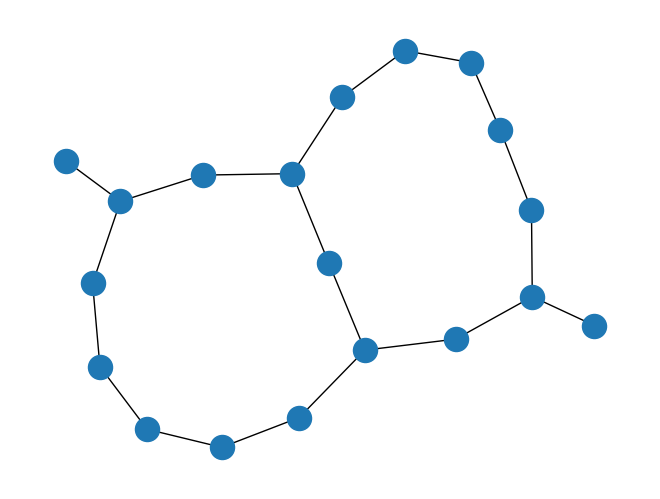

In [13]:
hh = CouplingMap().from_heavy_hex(3)
hh_graph = nx.Graph(list(hh.get_edges()))
nx.draw(hh_graph)

In [26]:
fake_algiers = FakeAlgiers()
cmap = fake_algiers.coupling_map

In [27]:
cmap.physical_qubits

NodeIndices[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26]

In [29]:
cmap.get_edges()

EdgeList[(0, 1), (1, 0), (1, 2), (1, 4), (2, 1), (2, 3), (3, 2), (3, 5), (4, 1), (4, 7), (5, 3), (5, 8), (6, 7), (7, 4), (7, 6), (7, 10), (8, 5), (8, 9), (8, 11), (9, 8), (10, 7), (10, 12), (11, 8), (11, 14), (12, 10), (12, 13), (12, 15), (13, 12), (13, 14), (14, 11), (14, 13), (14, 16), (15, 12), (15, 18), (16, 14), (16, 19), (17, 18), (18, 15), (18, 17), (18, 21), (19, 16), (19, 20), (19, 22), (20, 19), (21, 18), (21, 23), (22, 19), (22, 25), (23, 21), (23, 24), (24, 23), (24, 25), (25, 22), (25, 24), (25, 26), (26, 25)]

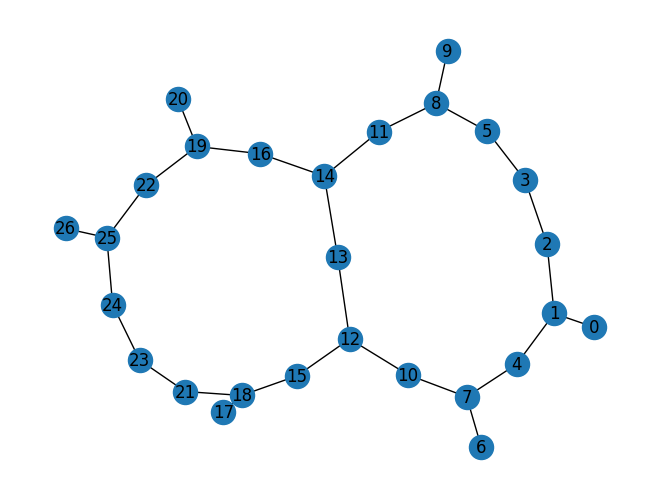

In [33]:

hh_graph = nx.Graph(list(cmap.get_edges()))
nx.draw(hh_graph,with_labels=True)

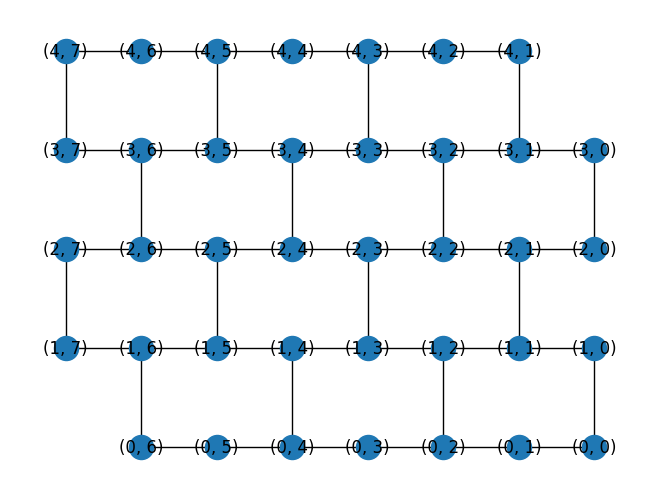

In [9]:
rows = 3
cols = 4
hex = nx.hexagonal_lattice_graph(rows,cols)
nx.draw(hex, pos={node: (-node[1], node[0]) for node in hex.nodes}, with_labels=True)

In [ ]:
rows = 3
cols = 4
hex = nx.hexagonal_lattice_graph(rows,cols)
coupling_graph = nx.Graph()
counter = 0
mapping = {}
index_to_name_mapping = {}

a_nodes = []
b_nodes = []

for node in hex.nodes:
    coupling_graph.add_node(counter)
    mapping[node] = counter
    index_to_name_mapping[counter] = node
    counter += 1
for edge in hex.edges:
    coupling_graph.add_node(counter)
    
    if edge[0][0] != edge[1][0]:
        # this logic is wrong - parity. breaks for (3,4) case
        if (edge[0][0] == 0 and edge[0][1] == 2*rows) or (edge[0][0] == cols-1 and edge[0][1] == 2*rows):
            pass
        elif edge[0][0] % 2 == 0 and edge[0][1] % 4 == 2:
            a_nodes.append(edge)
        elif edge[0][0] % 2 == 0 and edge[0][1] % 4 == 0 and not edge[0][1] == 0:
            b_nodes.append(edge)
        elif edge[0][0] % 2 == 1 and edge[0][1] % 4 == 1 and not edge[0][1] == 2*rows+1:
            a_nodes.append(edge)
        elif edge[0][0] % 2 == 1 and edge[0][1] % 4 == 3:
            b_nodes.append(edge)
            
    
    mapping[edge] = counter
    mapping[edge[::-1]] = counter
    index_to_name_mapping[counter] = edge
    counter += 1
    
    
for node in hex.nodes:
    for edge in hex.edges(node):
        coupling_graph.add_edge(mapping[node], mapping[edge])

In [11]:
line_node_counters = [mapping[((0, 2* rows), (1, 2*rows))]]
for col_idx in range(2*rows,0,-1):
    line_node_counters.append(mapping[(0, col_idx)])
    line_node_counters.append(mapping[((0, col_idx),(0, col_idx-1))])
line_node_counters.append(mapping[(0, 0)])
line_node_counters.append(mapping[((0, 0), (1, 0))])

# for col in range(cols+1):
#     if col % 2 == 1:
#         for col_idx in range(2*rows+2):
#             line_node_counters.append(mapping[(row_idx, 0)])


In [12]:
line_node_counters

[47, 6, 46, 5, 44, 4, 43, 3, 41, 2, 40, 1, 38, 0, 39]

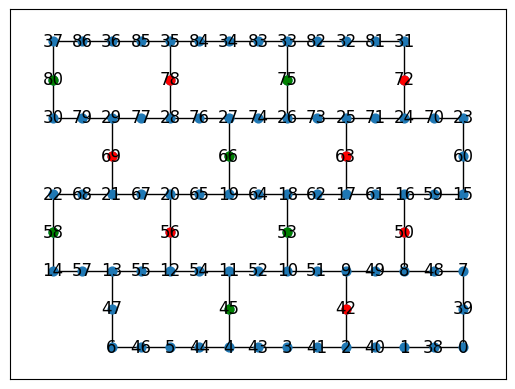

In [7]:
pos = {
    node: (-index_to_name_mapping[node][1], index_to_name_mapping[node][0]) if type(index_to_name_mapping[node][0]) is int 
        else (-(index_to_name_mapping[node][0][1]+index_to_name_mapping[node][1][1])/2, (index_to_name_mapping[node][0][0]+index_to_name_mapping[node][1][0])/2) 
        for node in coupling_graph.nodes
}
nx.draw_networkx(coupling_graph, pos=pos, node_size=40, labels=None)
nx.draw_networkx_nodes(coupling_graph, pos, nodelist=[mapping[x] for x in a_nodes],node_size=40, node_color='red')
nx.draw_networkx_nodes(coupling_graph, pos, nodelist=[mapping[x] for x in b_nodes],node_size=40, node_color='green')

In [ ]:
swap_layer0 = tuple((line[i], line[i + 1]) for i in range(0, len(line) - 1, 2))
swap_layer1 = tuple((line[i], line[i + 1]) for i in range(1, len(line) - 1, 2))

In [68]:
coupling_map = CouplingMap(
    list(coupling_graph.edges) + [e[::-1] for e in coupling_graph.edges]
)

Have the coupling with the appropriate colouring
Need to implement the swap strategy

In [4]:
from qiskit.transpiler.coupling import CouplingMap


In [10]:
backend = AerSimulator(num_qubits=3, coupling_map=CouplingMap([[1,2],[2,3]]))

AttributeError: can't set attribute 'num_qubits'

In [ ]:
backend.num_qubits

[(1, 2), (2, 3)]